# COMBINED DATA FIGURE 

In [1]:
from pynwb import NWBHDF5IO
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np 
import os
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde
import cv2
from scipy.signal import butter, filtfilt
from scipy.signal import savgol_filter

from scipy.ndimage import gaussian_filter
from pathlib import Path

# Set working directory to test this out locally 
os.chdir('/Users/nicole.burke/OneDrive - Child Mind Institute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data')
print(os.getcwd())

### Custom functions for script 
def descr_stats(df, column_name):
    stats = df[column_name].agg(
        mean='mean',
        min='min',
        max='max',
        std='std'
    )
    print(f"Summary stats for column: {column_name}")
    print(stats)

    return stats

/Users/nicole.burke/Library/CloudStorage/OneDrive-ChildMindInstitute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data


## The *Present* DS1

In [2]:
#### Read in data 
present_df = pd.read_csv('present_ds1_df.csv')
present_df = present_df.iloc[:, 1:]
print(present_df.head())
print(present_df.shape)

   x_corr_pixels  y_corr_pixels     times      subjectID
0          564.2          631.6 -1.122725  sub-A00010201
1          564.3          630.9 -1.117170  sub-A00010201
2          564.5          629.8 -1.111614  sub-A00010201
3          564.7          628.0 -1.106058  sub-A00010201
4          564.3          628.4 -1.100503  sub-A00010201
(7500629, 4)


In [ ]:
### descriptive stats 
present_number_subjects = len(present_df['subjectID'].unique())
print(f"Number of subjects in PRESENT: {present_number_subjects}")

xx = descr_stats(present_df, 'x_corr_pixels')
print("*"*10)
yy = descr_stats(present_df, 'y_corr_pixels')

In [ ]:
records = []

for subj, grp in present_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["x_corr_pixels"].values
    y     = grp["y_corr_pixels"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["x_corr_pixels", "y_corr_pixels"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: PRESENT data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### The *Present* FILTERED

In [12]:
### present
# x
present_mean_x = present_df['x_corr_pixels'].mean()
present_sd_x = present_df['x_corr_pixels'].std()
print(f"present x_corr mean: {present_mean_x} and std: {present_sd_x}")
present_upper_x = present_mean_x + (present_sd_x*2.5)
present_lower_x = present_mean_x - (present_sd_x*2.5)
print(f"present x_corr upper: {present_upper_x} and lower: {present_lower_x}")
print(f"present x_corr min x: {present_df['x_corr_pixels'].min()} and max x: {present_df['x_corr_pixels'].max()}")
print(f"present number of samples: {len(present_df)}")

# filter out oultiers 
present_df_filtered = present_df[
    (present_df['x_corr_pixels'] <= present_upper_x) &
    (present_df['x_corr_pixels'] >= present_lower_x)
]
print(f"Filter present mean x: {present_df_filtered['x_corr_pixels'].mean()}, x_min: {present_df_filtered['x_corr_pixels'].min()}, x_max: {present_df_filtered['x_corr_pixels'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")

print("*"*50)

# y 
present_mean_y = present_df['y_corr_pixels'].mean()
present_sd_y = present_df['y_corr_pixels'].std()
print(f"present y_corr mean: {present_mean_y} and std: {present_sd_y}")
present_upper_y = present_mean_y + (present_sd_y*2.5)
present_lower_y = present_mean_y - (present_sd_y*2.5)
print(f"present y_corr upper: {present_upper_y} and lower: {present_lower_y}")
print(f"present y_corr min y: {present_df['y_corr_pixels'].min()} and max y: {present_df['y_corr_pixels'].max()}")

# filter out outliers 
present_df_filtered = present_df_filtered[
    (present_df_filtered['y_corr_pixels'] <= present_upper_y) &
    (present_df_filtered['y_corr_pixels'] >= present_lower_y)
]
print(f"Filtered present mean y: {present_df_filtered['y_corr_pixels'].mean()}, y_min: {present_df_filtered['y_corr_pixels'].min()}, y_max: {present_df_filtered['y_corr_pixels'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")
print(f"Filter present number of subjects: {len(present_df['subjectID'].unique())}")

present x_corr mean: 653.1171967844298 and std: 82.66069334043692
present x_corr upper: 859.768930135522 and lower: 446.4654634333375
present x_corr min x: -3160.4 and max x: 3147.4
present number of samples: 7500629
Filter present mean x: 654.9725570006368, x_min: 446.5, x_max: 859.7
Filter present number of samples lost: 136106
**************************************************
present y_corr mean: 410.2976534234662 and std: 127.21930195190917
present y_corr upper: 728.3459083032392 and lower: 92.2493985436933
present y_corr min y: -3263.3 and max y: 3275.8
Filtered present mean y: 405.2632955712474, y_min: 92.3, y_max: 728.3
Filter present number of samples lost: 285279
Filter present number of subjects: 192


### The *Present* Plot RAW data 

In [ ]:
plt.plot(present_df['times'], present_df['x_corr_pixels'])
plt.title("RAW Present: x_corr_pixels x Time")
plt.show()

plt.plot(present_df_filtered['times'], present_df_filtered['x_corr_pixels'])
plt.ylim(-500,1500)
plt.title("FILTERED Present: x_corr_pixels x Time")
plt.show()


### The *Present* STANDARIZED

In [ ]:
# present 
present_df_standard = present_df_filtered
x_min_present = present_df_filtered['x_corr_pixels'].min()
x_max_present = present_df_filtered['x_corr_pixels'].max()
present_df_standard['x_norm'] = (present_df_standard['x_corr_pixels'] - x_min_present) / (x_max_present - x_min_present)
x_norm = descr_stats(present_df_standard, 'x_norm')

print("*"*50)

y_min_present = present_df_filtered['y_corr_pixels'].min()
y_max_present = present_df_filtered['y_corr_pixels'].max()
present_df_standard['y_norm'] = (present_df_standard['y_corr_pixels'] - y_min_present) / (y_max_present - y_min_present)
y_norm = descr_stats(present_df_standard, 'y_norm')

## The *Present* DS2

In [46]:
#### Read in data 
present_df2 = pd.read_csv('present_ds2_right_eye_df.csv')
present_df2 = present_df2.iloc[:, 1:]
print(present_df2.head())
print(present_df2.shape)

    rightEyeX   rightEyeY     times      subjectID
0  629.099976  518.599976 -1.367178  sub-A00008326
1  629.700012  519.400024 -1.365070  sub-A00008326
2  629.700012  519.400024 -1.363065  sub-A00008326
3  627.400024  524.000000 -1.361112  sub-A00008326
4  623.799988  529.200012 -1.359141  sub-A00008326
(12527062, 4)


In [ ]:
### descriptive stats 
present_number_subjects = len(present_df2['subjectID'].unique())
print(f"Number of subjects in PRESENT: {present_number_subjects}")

xx = descr_stats(present_df2, 'rightEyeX')
print("*"*10)
yy = descr_stats(present_df2, 'rightEyeY')

In [ ]:
records = []

for subj, grp in present_df2.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["rightEyeX"].values
    y     = grp["rightEyeY"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["rightEyeX", "rightEyeY"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: PRESENT data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### The *Present* DS2 FILTERED 

In [ ]:
### present
# x
present_mean_x = present_df2['rightEyeX'].mean()
present_sd_x = present_df2['rightEyeX'].std()
print(f"present x_corr mean: {present_mean_x} and std: {present_sd_x}")
present_upper_x = present_mean_x + (present_sd_x*2.5)
present_lower_x = present_mean_x - (present_sd_x*2.5)
print(f"present x_corr upper: {present_upper_x} and lower: {present_lower_x}")
print(f"present x_corr min x: {present_df2['rightEyeX'].min()} and max x: {present_df2['rightEyeX'].max()}")
print(f"present number of samples: {len(present_df2)}")

# filter out oultiers 
present_df2_filtered = present_df2[
    (present_df2['rightEyeX'] <= present_upper_x) &
    (present_df2['rightEyeX'] >= present_lower_x)
]
print(f"Filter present mean x: {present_df2_filtered['rightEyeX'].mean()}, x_min: {present_df2_filtered['rightEyeX'].min()}, x_max: {present_df2_filtered['rightEyeX'].max()}")
print(f"Filter present number of samples lost: {len(present_df2)-len(present_df2_filtered)}")

print("*"*50)

# y 
present_mean_y = present_df2['rightEyeY'].mean()
present_sd_y = present_df2['rightEyeY'].std()
print(f"present y_corr mean: {present_mean_y} and std: {present_sd_y}")
present_upper_y = present_mean_y + (present_sd_y*2.5)
present_lower_y = present_mean_y - (present_sd_y*2.5)
print(f"present y_corr upper: {present_upper_y} and lower: {present_lower_y}")
print(f"present y_corr min y: {present_df2['rightEyeY'].min()} and max y: {present_df2['rightEyeY'].max()}")

# filter out outliers 
present_df2_filtered = present_df2_filtered[
    (present_df2_filtered['rightEyeY'] <= present_upper_y) &
    (present_df2_filtered['rightEyeY'] >= present_lower_y)
]
print(f"Filtered present mean y: {present_df2_filtered['rightEyeY'].mean()}, y_min: {present_df2_filtered['rightEyeY'].min()}, y_max: {present_df2_filtered['rightEyeY'].max()}")
print(f"Filter present number of samples lost: {len(present_df2)-len(present_df2_filtered)}")
print(f"Filter present number of subjects: {len(present_df2['subjectID'].unique())}")

### The *Present* DS2 STANDARIZED 

In [ ]:
# present 
present_df2_standard = present_df2_filtered
x_min_present = present_df2_filtered['rightEyeX'].min()
x_max_present = present_df2_filtered['rightEyeX'].max()
present_df2_standard['x_norm'] = (present_df2_standard['rightEyeX'] - x_min_present) / (x_max_present - x_min_present)
x_norm = descr_stats(present_df2_standard, 'x_norm')

print("*"*50)

y_min_present = present_df2_filtered['rightEyeY'].min()
y_max_present = present_df2_filtered['rightEyeY'].max()
present_df2_standard['y_norm'] = (present_df2_standard['rightEyeY'] - y_min_present) / (y_max_present - y_min_present)
y_norm = descr_stats(present_df2_standard, 'y_norm')

## Combine *Present* DS1 and DS2

In [ ]:
cols = ['times', 'subjectID', 'x_norm', 'y_norm']
present_df_merge = present_df_standard[cols]
present_df2_merge = present_df2_standard[cols]

present_combined_df = pd.concat([present_df_merge, present_df2_merge])
print(present_combined_df.head())

## The *Present* PLOT

### Calculate ISC 

In [ ]:
df = present_combined_df.copy()

# --- Interpolate onto time grid
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

x_mat, y_mat = [], []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    x_mat.append(np.interp(time_grid, d['times'], d['x_norm']))
    y_mat.append(np.interp(time_grid, d['times'], d['y_norm']))

x_mat = np.array(x_mat)  # shape: (n_subjects, n_timepoints)
y_mat = np.array(y_mat)

n = len(subjects)

# --- Vectorized LOO mean ---
# Instead of recomputing mean of 299 subjects each time,
# subtract current subject from grand sum and divide by (n-1)
x_sum = x_mat.sum(axis=0)
y_sum = y_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    x_loo_mean = (x_sum - x_mat[i]) / (n - 1)
    y_loo_mean = (y_sum - y_mat[i]) / (n - 1)

    isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
    isc_y, _ = pearsonr(y_mat[i], y_loo_mean)

    isc_results.append({
        "subjectID": subj,
        "ISC_x": isc_x,
        "ISC_y": isc_y,
        "ISC_mean": np.nanmean([isc_x, isc_y])
    })

isc_df = pd.DataFrame(isc_results)
# Rank by ISC_x
isc_df["rank_x"] = isc_df["ISC_x"].rank()  
isc_df["rank_y"] = isc_df["ISC_y"].rank()  
print(isc_df.head())
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

#### Merge ISC with present_combined_df

In [ ]:
test = present_combined_df.copy()
test = present_combined_df.merge(isc_df[['subjectID', "ISC_x", "ISC_y", 'rank_x', 'rank_y']], on="subjectID")
print(test.head())
# rename to present_combined_df 
present_combined_df = test.copy()
print(present_combined_df.head())

### Fixation X x Time 



#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_combined_df['times'],
    present_combined_df['x_norm'],
    gridsize=100,
)

# Add lines: 1:57 and 2:28
line_times = [117, 148]

# Add vertical dashed red lines
for t in line_times:
    plt.axvline(x=t, color='red', linestyle='--')

plt.colorbar(label='Density')
plt.xlim(-25, 230)
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('The Present: Fixation X over Time')

plt.show()

Raw Data

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_combined_df["times"], present_combined_df["x_norm"], linewidth=1, color="#2563eb", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Standarized X Position", fontsize=12)
ax.set_title("Gaze Position Over Time", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

#### Median and percentile looking

In [ ]:
# --- Time bins & percentiles ---
time_bins = np.linspace(present_combined_df["times"].min(), present_combined_df["times"].max(), 300)

present_combined_df["time_bin"] = pd.cut(present_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = present_combined_df.groupby("time_bin")["x_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized X Position", fontsize=11)
ax.set_title("The Present Fixation X x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# Add lines: 1:57 and 2:28
ax.axvline(x=117, color='red',linestyle='--')
ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    present_combined_df["times"],
    present_combined_df["rank_x"],
    C=present_combined_df["x_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze X position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_x"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_x"].min(),
#                          df["rank_x"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df.loc[isc_df['rank_x'] == r, 'ISC_x'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis 
plt.xlim(0,200)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("The Present: Z-Scored Fixation X Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

#### Frame x Frame Heatmap

In [ ]:
# --- Settings ---
VIDEO_PATH = "/Users/nicole.burke/Library/CloudStorage/OneDrive-ChildMindInstitute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/video_files/thepresent.mp4"
TIMESTAMPS = [137, 139, 141]  
WINDOW = 0.1
ASPECT_RATIO = 16 / 9 
# ASPECT_RATIO = 4 / 3

def extract_frame(video_path, timestamp_sec):
    """Extract a single frame from a video at a given timestamp."""
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_MSEC, timestamp_sec * 1000)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not extract frame at {timestamp_sec}s")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# def make_gaze_heatmap(x_norm, y_norm, frame_shape):
#     h, w = frame_shape[:2]
#     w_corrected = int(h * ASPECT_RATIO)  # CHANGED

#     x_px = x_norm * w_corrected          # CHANGED
#     y_px = y_norm * h

#     xx, yy = np.mgrid[0:w_corrected:200j, h:0:200j]  # CHANGED
#     positions = np.vstack([xx.ravel(), yy.ravel()])
#     values = np.vstack([x_px, y_px])
#     kde = gaussian_kde(values, bw_method=0.08)
#     density = kde(positions).reshape(200, 200).T

#     return density

def make_gaze_heatmap(x_norm, y_norm, frame_shape):
    h, w = frame_shape[:2]
    w_corrected = int(h * ASPECT_RATIO)

    # Work entirely in normalized 0-1 space for KDE
    xx, yy = np.mgrid[0:1:200j, 1:0:200j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x_norm, y_norm])
    kde = gaussian_kde(values, bw_method=0.03)  # now 0.05 means 5% of screen width
    density = kde(positions).reshape(200, 200).T

    return density

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, ts in zip(axes, TIMESTAMPS):
    # Extract video frame
    frame = extract_frame(VIDEO_PATH, ts)

    # Filter gaze data to window around timestamp
    window_df = present_combined_df[
        (present_combined_df["times"] >= ts - WINDOW) &
        (present_combined_df["times"] <= ts + WINDOW)
    ].dropna(subset=["x_norm", "y_norm"])

    # Compute heatmap
    density = make_gaze_heatmap(window_df["x_norm"].values, window_df["y_norm"].values, frame.shape)

    # Plot frame + overlay heatmap
    ax.imshow(frame, extent=[0, frame.shape[1], frame.shape[0], 0])
    ax.imshow(
        density,
        extent=[0, frame.shape[1], frame.shape[0], 0],
        cmap="inferno",
        alpha=0.55,
        norm=mcolors.PowerNorm(gamma=0.4)   # stretch colormap to show sparse gaze too
    )

    mins = ts // 60
    secs = ts % 60
    ax.set_title(f"{mins}:{secs:02d}", fontsize=12, fontweight="bold")
    ax.axis("off")

plt.suptitle("Gaze Heatmap by Timestamp", fontsize=14, fontweight="bold")
plt.tight_layout()
# plt.savefig("gaze_heatmaps.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()


# Trouble shoot 
for ts in TIMESTAMPS:
    window_df = present_combined_df[
        (present_combined_df["times"] >= ts - WINDOW) &
        (present_combined_df["times"] <= ts + WINDOW)
    ]
    print(f"t={ts}: {len(window_df)} rows, {window_df['subjectID'].nunique()} subjects")

print(present_combined_df["times"].sort_values().unique()[:20])

print(present_combined_df[["x_norm", "y_norm"]].describe())

In [ ]:
TIMESTAMPS = [137, 139, 141]  # 1:46, 1:47, 1:48 in seconds

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, ts in zip(axes, TIMESTAMPS):
    window_df = present_combined_df[
        np.isclose(present_combined_df["times"], ts, atol=0.01)
    ].dropna(subset=["x_norm", "y_norm"])

    # KDE over normalized 0-1 space (no pixel conversion needed)
    xx, yy = np.mgrid[0:1:200j, 0:1:200j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([window_df["x_norm"].values, window_df["y_norm"].values])
    kde = gaussian_kde(values, bw_method=0.08)
    density = kde(positions).reshape(200, 200).T

    ax.imshow(
        density,
        origin="upper",
        extent=[0, 1, 1, 0],
        cmap="hot",
        aspect="auto"
    )

    mins, secs = ts // 60, ts % 60
    ax.set_title(f"{mins}:{secs:02d}", fontsize=12, fontweight="bold")
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Gaze Heatmap by Timestamp", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("gaze_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()

#### NEW Frame by Frame

In [ ]:
"""
Gaze Heatmap on Video Frames — corrected for windowed video
-------------------------------------------------------------
Screen:  1920 x 1080
Video:   1280 x 720, centered on screen
         → left edge at x = (1920-1280)/2 = 320  (as proportion: 320/1920 = 0.1667)
         → top  edge at y = (1080-720)/2  = 180  (as proportion: 180/1080 = 0.1667)
         → right edge at x = 1600/1920 = 0.8333
         → bottom edge at y = 900/1080  = 0.8333
"""
# ── 0. SCREEN / VIDEO GEOMETRY ────────────────────────────────────────────────

SCREEN_W, SCREEN_H = 1920, 1080
VIDEO_W,  VIDEO_H  = 1280, 720

# Video offset in pixels
OFFSET_X = (SCREEN_W - VIDEO_W) // 2   # 320px
# OFFSET_Y = (SCREEN_H - VIDEO_H) // 2   # 180px
OFFSET_Y = 280

# Video bounds in normalized screen coordinates [0, 1]
VIDEO_X_MIN = OFFSET_X / SCREEN_W      # 0.1667
VIDEO_X_MAX = (OFFSET_X + VIDEO_W) / SCREEN_W   # 0.8333
VIDEO_Y_MIN = OFFSET_Y / SCREEN_H      # 0.1667
VIDEO_Y_MAX = (OFFSET_Y + VIDEO_H) / SCREEN_H   # 0.8333

print(f"Video bounds in normalized coords:")
print(f"  X: [{VIDEO_X_MIN:.4f}, {VIDEO_X_MAX:.4f}]")
print(f"  Y: [{VIDEO_Y_MIN:.4f}, {VIDEO_Y_MAX:.4f}]")

# ── 1. SETTINGS ───────────────────────────────────────────────────────────────

VIDEO_PATH = "/Users/nicole.burke/Library/CloudStorage/OneDrive-ChildMindInstitute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/video_files/thepresent.mp4"
TIMESTAMPS = [137, 139, 141]
WINDOW     = 0.5        # seconds either side of timestamp — increase if heatmap looks sparse
BW_METHOD  = 0.08       # KDE bandwidth — smaller = tighter clusters


# ── 2. HELPERS ────────────────────────────────────────────────────────────────

def extract_frame(video_path, timestamp_sec):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_MSEC, timestamp_sec * 1000)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not extract frame at {timestamp_sec}s")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def remap_to_video(x_norm, y_norm):
    """
    Remap gaze from normalized screen coords [0,1] 
    to normalized video coords [0,1].
    
    Drops samples that fall outside the video window.
    """
    mask = (
        (x_norm >= VIDEO_X_MIN) & (x_norm <= VIDEO_X_MAX) &
        (y_norm >= VIDEO_Y_MIN) & (y_norm <= VIDEO_Y_MAX)
    )
    x_video = (x_norm[mask] - VIDEO_X_MIN) / (VIDEO_X_MAX - VIDEO_X_MIN)
    y_video = (y_norm[mask] - VIDEO_Y_MIN) / (VIDEO_Y_MAX - VIDEO_Y_MIN)
    return x_video, y_video, mask

# def remap_to_video(x_norm, y_norm):
#     y_norm_flipped = 1 - y_norm   # flip y before remapping
#     mask = (
#         (x_norm       >= VIDEO_X_MIN) & (x_norm       <= VIDEO_X_MAX) &
#         (y_norm_flipped >= VIDEO_Y_MIN) & (y_norm_flipped <= VIDEO_Y_MAX)
#     )
#     x_video = (x_norm[mask]        - VIDEO_X_MIN) / (VIDEO_X_MAX - VIDEO_X_MIN)
#     y_video = (y_norm_flipped[mask] - VIDEO_Y_MIN) / (VIDEO_Y_MAX - VIDEO_Y_MIN)
#     return x_video, y_video, mask


def make_gaze_heatmap(x_video_norm, y_video_norm, bw=BW_METHOD, grid_size=200):
    """
    Build KDE heatmap in video-normalized [0,1] coords.
    Returns density grid of shape (grid_size, grid_size).
    """
    if len(x_video_norm) < 2:
        return np.zeros((grid_size, grid_size))

    xx, yy    = np.mgrid[0:1:complex(0, grid_size), 1:0:complex(0, grid_size)]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values    = np.vstack([x_video_norm, y_video_norm])
    kde       = gaussian_kde(values, bw_method=bw)
    density   = kde(positions).reshape(grid_size, grid_size).T
    return density


# ── 3. PLOT ───────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, len(TIMESTAMPS), figsize=(6 * len(TIMESTAMPS), 5))
if len(TIMESTAMPS) == 1:
    axes = [axes]

for ax, ts in zip(axes, TIMESTAMPS):

    # Extract frame
    frame = extract_frame(VIDEO_PATH, ts)
    h, w  = frame.shape[:2]

    # Filter gaze window
    window_df = present_combined_df[
        (present_combined_df["times"] >= ts - WINDOW) &
        (present_combined_df["times"] <= ts + WINDOW)
    ].dropna(subset=["x_norm", "y_norm"])

    # Remap to video coordinates
    x_vid, y_vid, mask = remap_to_video(
        window_df["x_norm"].values,
        window_df["y_norm"].values
    )

    n_total  = len(window_df)
    n_in_vid = mask.sum()
    print(f"t={ts}s | window={WINDOW*2:.1f}s | {n_total} samples total | "
          f"{n_in_vid} inside video ({n_in_vid/n_total*100:.1f}%) | "
          f"{window_df['subjectID'].nunique()} subjects")

    # Build heatmap
    density = make_gaze_heatmap(x_vid, y_vid)

    # Plot frame — extent maps image to pixel coords
    ax.imshow(frame, extent=[0, w, h, 0])

    # Overlay heatmap — same extent as frame
    ax.imshow(
        density,
        extent=[0, w, h, 0],
        cmap="inferno",
        alpha=0.55,
        norm=mcolors.PowerNorm(gamma=0.4),
        origin="upper"
    )

    mins, secs = divmod(ts, 60)
    ax.set_title(f"{mins}:{secs:02d}  (n={n_in_vid} samples)", fontsize=12, fontweight="bold")
    ax.axis("off")

plt.suptitle("Gaze Heatmap — The Present", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("gaze_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()


# ── 4. DIAGNOSTIC: check gaze coverage ───────────────────────────────────────

print("\n── x_norm / y_norm summary ──")
print(present_combined_df[["x_norm", "y_norm"]].describe().round(4))

print(f"\n── Fraction of samples inside video bounds ──")
in_bounds = (
    present_combined_df["x_norm"].between(VIDEO_X_MIN, VIDEO_X_MAX) &
    present_combined_df["y_norm"].between(VIDEO_Y_MIN, VIDEO_Y_MAX)
)
print(f"  {in_bounds.sum()} / {len(present_combined_df)} "
      f"({in_bounds.mean()*100:.1f}%)")

In [ ]:
print(present_combined_df.columns)

### Fixation Y x Time

#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_combined_df['times'],
    present_combined_df['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlim(-25, 230)
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('The Present: Fixation Y over Time')

plt.show()

#### Median and percentile looking

In [ ]:
# --- Time bins & percentiles ---
time_bins = np.linspace(present_combined_df["times"].min(), present_combined_df["times"].max(), 300)

present_combined_df["time_bin"] = pd.cut(present_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = present_combined_df.groupby("time_bin")["y_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized Y Position", fontsize=11)
ax.set_title("The Present Fixation Y x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# Add lines: 1:57 and 2:28
ax.axvline(x=117, color='red',linestyle='--')
ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    present_combined_df["times"],
    present_combined_df["rank_y"],
    C=present_combined_df["y_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze Y position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_y"].min(),
#                          df["rank_y"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df.loc[isc_df['rank_y'] == r, 'ISC_y'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# shorten graph 
plt.xlim(0,200)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("The Present: Z-Scored Fixation Y Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

### Polar Derivative 

#### Calculate Polar Derivative

In [ ]:
"""
Polar Coordinate Distance Derivative
-------------------------------------
Computes radial distance from screen center and its time derivative
for combined (both trackers) normalized gaze data.

Input columns: times, subjectID, x_norm, y_norm, time_bin
Output: adds r (radial distance) and r_deriv (derivative) columns
"""
# 1. COMPUTE POLAR DISTANCE
# Reference point = screen center in normalized coordinates

x_ref = 0.5
y_ref = 0.5

present_combined_df["r"] = np.sqrt(
    (present_combined_df["x_norm"] - x_ref) ** 2 +
    (present_combined_df["y_norm"] - y_ref) ** 2
)

# 2. COMPUTE DERIVATIVE PER SUBJECT 
# np.gradient uses central differences — robust at interior points,
# one-sided differences at the edges.
# We sort by time within each subject to ensure correct ordering.

present_combined_df = present_combined_df.sort_values(
    ["subjectID", "times"]
).reset_index(drop=True)

# by index - this was wrong! 
# present_combined_df["r_deriv"] = (
#     present_combined_df
#     .groupby("subjectID")["r"]
#     .transform(lambda s: np.gradient(s.values, s.index))
# )

present_combined_df["r_deriv"] = (
    present_combined_df
    .groupby("subjectID")["r"]
    .transform(lambda s: np.gradient(
        s.values,
        present_combined_df.loc[s.index, "times"].values  # actual time in seconds
    ))
)

# 3. SANITY CHECKS 

print("── Radial distance (r) ──")
print(present_combined_df["r"].describe().round(4))

print("\n── Derivative (r_deriv) ──")
print(present_combined_df["r_deriv"].describe().round(4))

# Flag any subjects with suspiciously large derivatives (likely residual outliers)
subj_max_deriv = (
    present_combined_df
    .groupby("subjectID")["r_deriv"]
    .apply(lambda s: s.abs().quantile(0.99))
    .sort_values(ascending=False)
)
print("\n── 99th percentile |r_deriv| per subject (top 10) ──")
print(subj_max_deriv.head(10).round(4))

# ── 4. OPTIONAL: CLIP EXTREME DERIVATIVES ────────────────────────────────────
# If residual outliers are causing spikes in r_deriv, clip at a threshold.
# Inspect the distribution first before uncommenting.

# deriv_threshold = present_combined_df["r_deriv"].abs().quantile(0.99)
# present_combined_df["r_deriv"] = present_combined_df["r_deriv"].clip(
#     -deriv_threshold, deriv_threshold
# )
# print(f"\nClipped r_deriv to ±{deriv_threshold:.4f}")

print("\nDone. New columns added: 'r', 'r_deriv'")
print(present_combined_df[["subjectID", "times", "x_norm", "y_norm", "r", "r_deriv"]].head(10))

#### Calculate new ISC with Polar Derivative 

In [ ]:
df = present_combined_df.copy()

# --- Interpolate r_deriv onto time grid
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

r_mat = []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    r_mat.append(np.interp(time_grid, d['times'], d['r_deriv']))

r_mat = np.array(r_mat)  # shape: (n_subjects, n_timepoints)

n = len(subjects)

# --- Vectorized LOO mean
r_sum = r_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    r_loo_mean = (r_sum - r_mat[i]) / (n - 1)
    isc_r, _   = pearsonr(r_mat[i], r_loo_mean)

    isc_results.append({
        "subjectID" : subj,
        "ISC_rderiv": isc_r,
    })

isc_rderiv_df = pd.DataFrame(isc_results)
isc_rderiv_df["rank_rderiv"] = isc_rderiv_df["ISC_rderiv"].rank()

print(isc_rderiv_df.describe().round(4))
print(isc_rderiv_df.sort_values("ISC_rderiv", ascending=False).head(10))
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

Merge new ISC ranks with present_combined_df

In [ ]:
test = present_combined_df.copy()
# print(test.head())
test = test.merge(isc_rderiv_df[['subjectID', 'ISC_rderiv', 'rank_rderiv']], on='subjectID')
# print(test.head())
present_combined_df = test.copy()
print(present_combined_df.head())

#### Plot Polar Derivate with ISC 

In [ ]:
# ── Step 3: Pivot to subject × time_bin matrix ───────────────────────────────
# time_bin should already be in your present_combined_df; if not:
present_combined_df["time_bin"] = pd.cut(present_combined_df["times"], bins=300, labels=False)

pivot = (
    present_combined_df.groupby(["rank_rderiv", "time_bin"])["r_deriv"]
    .mean()
    .unstack(level="time_bin")   # rows = subjects (ranked), cols = time bins
)

# ── Step 4: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Symmetric colormap centered at 0
vmax = np.nanpercentile(np.abs(pivot.values), 95)  # robust, ignores extreme spikes

im = ax.imshow(
    pivot.values,
    aspect="auto",
    origin="lower",                          # rank 1 at bottom
    cmap="RdBu_r",                           # diverging: red=moving away, blue=moving toward center
    vmin=-vmax,
    vmax=vmax,
    interpolation="nearest"
)

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Polar Distance Derivative", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# ── Axes ──────────────────────────────────────────────────────────────────────
# Map time bin indices back to seconds for x ticks
time_bins  = pivot.columns.values
time_vals  = present_combined_df.groupby("time_bin")["times"].mean().reindex(time_bins).values
n_ticks    = 8
tick_idx   = np.linspace(0, len(time_bins) - 1, n_ticks, dtype=int)
ax.set_xticks(tick_idx)
ax.set_xticklabels([f"{time_vals[i]:.0f}s" for i in tick_idx], fontsize=9)

# # Y axis: show ISC values at a few tick positions
# n_yticks    = 6
# subj_ranks  = pivot.index.values
# ytick_idx   = np.linspace(0, len(subj_ranks) - 1, n_yticks, dtype=int)
# ytick_ranks = subj_ranks[ytick_idx]
# ytick_labels = [
#     f"{present_combined_df.loc[present_combined_df['rank_rderiv'] == r, 'ISC_rderiv'].values[0]:.2f}"
#     for r in ytick_ranks
# ]
# ax.set_yticks(ytick_idx)
# ax.set_yticklabels(ytick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis:
start_time = -1
end_time = 201

start_idx = np.argmin(np.abs(time_vals - start_time))
end_idx   = np.argmin(np.abs(time_vals - end_time))

ax.set_xlim(start_idx, end_idx)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("The Present: Polar Derivative × Time, Subjects Ranked by ISC",
             fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("polar_deriv_raster.png", dpi=300, bbox_inches="tight")
plt.show()

## *Sherlock* DS1

In [ ]:
### read in data 
sherlock_df = pd.read_csv("sherlock_ds1_df.csv")
sherlock_df = sherlock_df.iloc[:, 1:]
print(sherlock_df.head())
print(sherlock_df.shape)

In [ ]:
### descriptive stats 
sherlock_number_subjects = len(sherlock_df['subjectID'].unique())
print(f"Number of subjects in SHERLOCK: {sherlock_number_subjects}")

xx = descr_stats(sherlock_df, 'x_corr_pixels')
print("*"*10)
yy = descr_stats(sherlock_df, 'y_corr_pixels')

In [ ]:
records = []

for subj, grp in sherlock_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["x_corr_pixels"].values
    y     = grp["y_corr_pixels"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["x_corr_pixels", "y_corr_pixels"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: SHERLOCK data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### *Sherlock* FILTERED

In [ ]:
### sherlock
# x
sherlock_mean_x = sherlock_df['x_corr_pixels'].mean()
sherlock_sd_x = sherlock_df['x_corr_pixels'].std()
print(f"sherlock x_corr mean: {sherlock_mean_x} and std: {sherlock_sd_x}")
sherlock_upper_x = sherlock_mean_x + (sherlock_sd_x*2.5)
sherlock_lower_x = sherlock_mean_x - (sherlock_sd_x*2.5)
print(f"sherlock x_corr upper: {sherlock_upper_x} and lower: {sherlock_lower_x}")
print(f"sherlock x_corr min x: {sherlock_df['x_corr_pixels'].min()} and max x: {sherlock_df['x_corr_pixels'].max()}")
print(f"sherlock number of samples: {len(sherlock_df)}")

# filter out oultiers 
sherlock_df_filtered = sherlock_df[
    (sherlock_df['x_corr_pixels'] <= sherlock_upper_x) &
    (sherlock_df['x_corr_pixels'] >= sherlock_lower_x)
]
print(f"Filter sherlock mean x: {sherlock_df_filtered['x_corr_pixels'].mean()}, x_min: {sherlock_df_filtered['x_corr_pixels'].min()}, x_max: {sherlock_df_filtered['x_corr_pixels'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")

print("*"*50)

# y 
sherlock_mean_y = sherlock_df['y_corr_pixels'].mean()
sherlock_sd_y = sherlock_df['y_corr_pixels'].std()
print(f"sherlock y_corr mean: {sherlock_mean_y} and std: {sherlock_sd_y}")
sherlock_upper_y = sherlock_mean_y + (sherlock_sd_y*2.5)
sherlock_lower_y = sherlock_mean_y - (sherlock_sd_y*2.5)
print(f"sherlock y_corr upper: {sherlock_upper_y} and lower: {sherlock_lower_y}")
print(f"sherlock y_corr min y: {sherlock_df['y_corr_pixels'].min()} and max y: {sherlock_df['y_corr_pixels'].max()}")

# filter out outliers 
sherlock_df_filtered = sherlock_df_filtered[
    (sherlock_df_filtered['y_corr_pixels'] <= sherlock_upper_y) &
    (sherlock_df_filtered['y_corr_pixels'] >= sherlock_lower_y)
]
print(f"Filtered sherlock mean y: {sherlock_df_filtered['y_corr_pixels'].mean()}, y_min: {sherlock_df_filtered['y_corr_pixels'].min()}, y_max: {sherlock_df_filtered['y_corr_pixels'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")
print(f"Filter sherlock number of subjects: {len(sherlock_df['subjectID'].unique())}")

### *Sherlock* STANDARIZED

In [ ]:
# sherlock 
sherlock_df_standard = sherlock_df_filtered
x_min_sherlock = sherlock_df_filtered['x_corr_pixels'].min()
x_max_sherlock = sherlock_df_filtered['x_corr_pixels'].max()
sherlock_df_standard['x_norm'] = (sherlock_df_standard['x_corr_pixels'] - x_min_sherlock) / (x_max_sherlock - x_min_sherlock)
x_norm = descr_stats(sherlock_df_standard, 'x_norm')

print("*"*50)

y_min_sherlock = sherlock_df_filtered['y_corr_pixels'].min()
y_max_sherlock = sherlock_df_filtered['y_corr_pixels'].max()
sherlock_df_standard['y_norm'] = (sherlock_df_standard['y_corr_pixels'] - y_min_sherlock) / (y_max_sherlock - y_min_sherlock)
y_norm = descr_stats(sherlock_df_standard, 'y_norm')

## *Sherlock* DS2

In [ ]:
### read in data 
sherlock_df2 = pd.read_csv("sherlock_ds2_right_eye_df.csv")
sherlock_df2 = sherlock_df2.iloc[:, 1:]
print(sherlock_df2.head())
print(sherlock_df2.shape)

In [ ]:
### descriptive stats 
sherlock_number_subjects = len(sherlock_df2['subjectID'].unique())
print(f"Number of subjects in SHERLOCK: {sherlock_number_subjects}")

xx = descr_stats(sherlock_df2, 'rightEyeX')
print("*"*10)
yy = descr_stats(sherlock_df2, 'rightEyeY')

In [ ]:
records = []

for subj, grp in sherlock_df2.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["rightEyeX"].values
    y     = grp["rightEyeY"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["rightEyeX", "rightEyeY"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### *Sherlock* DS2 FILTERED 

In [ ]:
### sherlock
# x
sherlock_mean_x = sherlock_df2['rightEyeX'].mean()
sherlock_sd_x = sherlock_df2['rightEyeX'].std()
print(f"sherlock x_corr mean: {sherlock_mean_x} and std: {sherlock_sd_x}")
sherlock_upper_x = sherlock_mean_x + (sherlock_sd_x*2.5)
sherlock_lower_x = sherlock_mean_x - (sherlock_sd_x*2.5)
print(f"sherlock x_corr upper: {sherlock_upper_x} and lower: {sherlock_lower_x}")
print(f"sherlock x_corr min x: {sherlock_df2['rightEyeX'].min()} and max x: {sherlock_df2['rightEyeX'].max()}")
print(f"sherlock number of samples: {len(sherlock_df2)}")

# filter out oultiers 
sherlock_df2_filtered = sherlock_df2[
    (sherlock_df2['rightEyeX'] <= sherlock_upper_x) &
    (sherlock_df2['rightEyeX'] >= sherlock_lower_x)
]
print(f"Filter sherlock mean x: {sherlock_df2_filtered['rightEyeX'].mean()}, x_min: {sherlock_df2_filtered['rightEyeX'].min()}, x_max: {sherlock_df2_filtered['rightEyeX'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df2)-len(sherlock_df2_filtered)}")

print("*"*50)

# y 
sherlock_mean_y = sherlock_df2['rightEyeY'].mean()
sherlock_sd_y = sherlock_df2['rightEyeY'].std()
print(f"sherlock y_corr mean: {sherlock_mean_y} and std: {sherlock_sd_y}")
sherlock_upper_y = sherlock_mean_y + (sherlock_sd_y*2.5)
sherlock_lower_y = sherlock_mean_y - (sherlock_sd_y*2.5)
print(f"sherlock y_corr upper: {sherlock_upper_y} and lower: {sherlock_lower_y}")
print(f"sherlock y_corr min y: {sherlock_df2['rightEyeY'].min()} and max y: {sherlock_df2['rightEyeY'].max()}")

# filter out outliers 
sherlock_df2_filtered = sherlock_df2_filtered[
    (sherlock_df2_filtered['rightEyeY'] <= sherlock_upper_y) &
    (sherlock_df2_filtered['rightEyeY'] >= sherlock_lower_y)
]
print(f"Filtered sherlock mean y: {sherlock_df2_filtered['rightEyeY'].mean()}, y_min: {sherlock_df2_filtered['rightEyeY'].min()}, y_max: {sherlock_df2_filtered['rightEyeY'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df2)-len(sherlock_df2_filtered)}")
print(f"Filter sherlock number of subjects: {len(sherlock_df2['subjectID'].unique())}")

### *Sherlock* DS2 STANDARIZED

In [ ]:
# sherlock 
sherlock_df2_standard = sherlock_df2_filtered
x_min_sherlock = sherlock_df2_filtered['rightEyeX'].min()
x_max_sherlock = sherlock_df2_filtered['rightEyeX'].max()
sherlock_df2_standard['x_norm'] = (sherlock_df2_standard['rightEyeX'] - x_min_sherlock) / (x_max_sherlock - x_min_sherlock)
x_norm = descr_stats(sherlock_df2_standard, 'x_norm')

print("*"*50)

y_min_sherlock = sherlock_df2_filtered['rightEyeY'].min()
y_max_sherlock = sherlock_df2_filtered['rightEyeY'].max()
sherlock_df2_standard['y_norm'] = (sherlock_df2_standard['rightEyeY'] - y_min_sherlock) / (y_max_sherlock - y_min_sherlock)
y_norm = descr_stats(sherlock_df2_standard, 'y_norm')

## Combine *Sherlock* DS1 and DS2

In [ ]:
cols = ['times', 'subjectID', 'x_norm', 'y_norm']
sherlock_df_merge = sherlock_df_standard[cols]
sherlock_df2_merge = sherlock_df2_standard[cols]

sherlock_combined_df = pd.concat([sherlock_df_merge, sherlock_df2_merge])
print(sherlock_combined_df.head())


## *Sherlock* PLOT - combined data

### Calculate ISC 

In [ ]:
df = sherlock_combined_df.copy()

# --- Interpolate onto time grid (same as before) ---
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

x_mat, y_mat = [], []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    x_mat.append(np.interp(time_grid, d['times'], d['x_norm']))
    y_mat.append(np.interp(time_grid, d['times'], d['y_norm']))

x_mat = np.array(x_mat)  # shape: (n_subjects, n_timepoints)
y_mat = np.array(y_mat)

n = len(subjects)

# --- Vectorized LOO mean ---
# Instead of recomputing mean of 299 subjects each time,
# subtract current subject from grand sum and divide by (n-1)
x_sum = x_mat.sum(axis=0)
y_sum = y_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    x_loo_mean = (x_sum - x_mat[i]) / (n - 1)
    y_loo_mean = (y_sum - y_mat[i]) / (n - 1)

    isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
    isc_y, _ = pearsonr(y_mat[i], y_loo_mean)

    isc_results.append({
        "subjectID": subj,
        "ISC_x": isc_x,
        "ISC_y": isc_y,
        "ISC_mean": np.nanmean([isc_x, isc_y])
    })

isc_df_sherlock = pd.DataFrame(isc_results)
isc_df_sherlock['rank_x'] = isc_df_sherlock['ISC_x'].rank()
isc_df_sherlock['rank_y'] = isc_df_sherlock['ISC_y'].rank()
print(isc_df_sherlock.head())
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

### Merge sherlock_combined_df with ISC_df

In [ ]:
test = sherlock_combined_df.copy()

### Fixation X x Time

#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_combined_df['times'],
    sherlock_combined_df['x_norm'],
    gridsize=100,
)

# Add lines: 2:04
line_times = [124]

# Add vertical dashed red lines
plt.axvline(x=line_times, color='red', linestyle='--')

plt.colorbar(label='Density')
plt.xlim(-50,650)
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('Sherlock: Fixation X over Time')

plt.show()

#### Median and percentile looking

In [ ]:
# --- Time bins & percentiles ---
time_bins = np.linspace(sherlock_combined_df["times"].min(), sherlock_combined_df["times"].max(), 300)

sherlock_combined_df["time_bin"] = pd.cut(sherlock_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = sherlock_combined_df.groupby("time_bin")["x_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized X Position", fontsize=11)
ax.set_title("Sherlock Fixation X x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# # Add lines: 1:57 and 2:28
# ax.axvline(x=117, color='red',linestyle='--')
# ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC 

In [ ]:
df = sherlock_combined_df.merge(isc_df_sherlock[["subjectID", "ISC_x", "rank_x"]], on="subjectID")

fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_x"],
    C=df["x_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze X position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_x"].min(),
#                          df["rank_x"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df_sherlock.loc[isc_df_sherlock['rank_x'] == r, 'ISC_x'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis
plt.xlim(0,610)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("Sherlock: Z-Scored Fixation X Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

### Fixation Y x Time

#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_combined_df['times'],
    sherlock_combined_df['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlim(-50,650)
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('Sherlock: Fixation Y over Time')

plt.show()

#### Median and percentile looking

In [ ]:
# --- Time bins & percentiles ---
time_bins = np.linspace(sherlock_combined_df["times"].min(), sherlock_combined_df["times"].max(), 300)

sherlock_combined_df["time_bin"] = pd.cut(sherlock_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = sherlock_combined_df.groupby("time_bin")["y_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized Y Position", fontsize=11)
ax.set_title("The Present Fixation Y x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# Add lines: 1:57 and 2:28
ax.axvline(x=117, color='red',linestyle='--')
ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC

In [ ]:
df = sherlock_combined_df.merge(isc_df_sherlock[["subjectID", "ISC_y", "rank_y"]], on="subjectID")

fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_y"],
    C=df["y_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze Y position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_y"].min(),
#                          df["rank_y"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df_sherlock.loc[isc_df_sherlock['rank_y'] == r, 'ISC_y'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis 
plt.xlim(0,610)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("Sherlock: Z-Scored Fixation Y Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

### Polar Derivative 

#### Calculcate Polar Derivative 

In [ ]:
"""
Polar Coordinate Distance Derivative
-------------------------------------
Computes radial distance from screen center and its time derivative
for combined (both trackers) normalized gaze data.

Input columns: times, subjectID, x_norm, y_norm, time_bin
Output: adds r (radial distance) and r_deriv (derivative) columns
"""
# ── 1. COMPUTE POLAR DISTANCE ─────────────────────────────────────────────────
# Reference point = screen center in normalized coordinates

x_ref = 0.5
y_ref = 0.5

sherlock_combined_df["r"] = np.sqrt(
    (sherlock_combined_df["x_norm"] - x_ref) ** 2 +
    (sherlock_combined_df["y_norm"] - y_ref) ** 2
)

# ── 2. COMPUTE DERIVATIVE PER SUBJECT ────────────────────────────────────────
# np.gradient uses central differences — robust at interior points,
# one-sided differences at the edges.
# We sort by time within each subject to ensure correct ordering.

sherlock_combined_df = sherlock_combined_df.sort_values(
    ["subjectID", "times"]
).reset_index(drop=True)

sherlock_combined_df["r_deriv"] = (
    sherlock_combined_df
    .groupby("subjectID")["r"]
    .transform(lambda s: np.gradient(s.values, s.index))
)

# ── 3. SANITY CHECKS ──────────────────────────────────────────────────────────

print("── Radial distance (r) ──")
print(sherlock_combined_df["r"].describe().round(4))

print("\n── Derivative (r_deriv) ──")
print(sherlock_combined_df["r_deriv"].describe().round(4))

# Flag any subjects with suspiciously large derivatives (likely residual outliers)
subj_max_deriv = (
    sherlock_combined_df
    .groupby("subjectID")["r_deriv"]
    .apply(lambda s: s.abs().quantile(0.99))
    .sort_values(ascending=False)
)
print("\n── 99th percentile |r_deriv| per subject (top 10) ──")
print(subj_max_deriv.head(10).round(4))

# ── 4. OPTIONAL: CLIP EXTREME DERIVATIVES ────────────────────────────────────
# If residual outliers are causing spikes in r_deriv, clip at a threshold.
# Inspect the distribution first before uncommenting.

# deriv_threshold = sherlock_combined_df["r_deriv"].abs().quantile(0.99)
# sherlock_combined_df["r_deriv"] = sherlock_combined_df["r_deriv"].clip(
#     -deriv_threshold, deriv_threshold
# )
# print(f"\nClipped r_deriv to ±{deriv_threshold:.4f}")

print("\nDone. New columns added: 'r', 'r_deriv'")
print(sherlock_combined_df[["subjectID", "times", "x_norm", "y_norm", "r", "r_deriv"]].head(10))

#### Calculate new ISC with Polar Derivative 

In [ ]:
df = sherlock_combined_df.copy()

# --- Interpolate r_deriv onto time grid
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

r_mat = []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    r_mat.append(np.interp(time_grid, d['times'], d['r_deriv']))

r_mat = np.array(r_mat)  # shape: (n_subjects, n_timepoints)

n = len(subjects)

# --- Vectorized LOO mean
r_sum = r_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    r_loo_mean = (r_sum - r_mat[i]) / (n - 1)
    isc_r, _   = pearsonr(r_mat[i], r_loo_mean)

    isc_results.append({
        "subjectID" : subj,
        "ISC_rderiv": isc_r,
    })

isc_rderiv_df = pd.DataFrame(isc_results)
isc_rderiv_df["rank_rderiv"] = isc_rderiv_df["ISC_rderiv"].rank()

print(isc_rderiv_df.describe().round(4))
print(isc_rderiv_df.sort_values("ISC_rderiv", ascending=False).head(10))
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

Merged new ISC with sherlock_combined_df 

In [ ]:
test = sherlock_combined_df.copy()
test = test.merge(isc_rderiv_df[['subjectID', 'ISC_rderiv', 'rank_rderiv']], on='subjectID')
print(test.head())
sherlock_combined_df = test.copy()


#### Plot Polar Derivate with ISC 

In [ ]:
# ── Step 3: Pivot to subject × time_bin matrix ───────────────────────────────
# time_bin should already be in your sherlock_combined_df; if not:
sherlock_combined_df["time_bin"] = pd.cut(sherlock_combined_df["times"], bins=300, labels=False)

pivot = (
    sherlock_combined_df.groupby(["rank_rderiv", "time_bin"])["r_deriv"]
    .mean()
    .unstack(level="time_bin")   # rows = subjects (ranked), cols = time bins
)

# ── Step 4: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Symmetric colormap centered at 0
vmax = np.nanpercentile(np.abs(pivot.values), 95)  # robust, ignores extreme spikes

im = ax.imshow(
    pivot.values,
    aspect="auto",
    origin="lower",                          # rank 1 at bottom
    cmap="RdBu_r",                           # diverging: red=moving away, blue=moving toward center
    vmin=-vmax,
    vmax=vmax,
    interpolation="nearest"
)

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Polar Distance Derivative", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# ── Axes ──────────────────────────────────────────────────────────────────────
# Map time bin indices back to seconds for x ticks
time_bins  = pivot.columns.values
time_vals  = sherlock_combined_df.groupby("time_bin")["times"].mean().reindex(time_bins).values
n_ticks    = 8
tick_idx   = np.linspace(0, len(time_bins) - 1, n_ticks, dtype=int)
ax.set_xticks(tick_idx)
ax.set_xticklabels([f"{time_vals[i]:.0f}s" for i in tick_idx], fontsize=9)

# # Y axis: show ISC values at a few tick positions
# n_yticks    = 6
# subj_ranks  = pivot.index.values
# ytick_idx   = np.linspace(0, len(subj_ranks) - 1, n_yticks, dtype=int)
# ytick_ranks = subj_ranks[ytick_idx]
# ytick_labels = [
#     f"{sherlock_combined_df.loc[sherlock_combined_df['rank_rderiv'] == r, 'ISC_rderiv'].values[0]:.2f}"
#     for r in ytick_ranks
# ]
# ax.set_yticks(ytick_idx)
# ax.set_yticklabels(ytick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis:
start_time = -1
end_time = 590

start_idx = np.argmin(np.abs(time_vals - start_time))
end_idx   = np.argmin(np.abs(time_vals - end_time))

ax.set_xlim(start_idx, end_idx)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("The Sherlock: Polar Derivative × Time, Subjects Ranked by ISC",
             fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("polar_deriv_raster.png", dpi=300, bbox_inches="tight")
# plt.show()

## *The Present* - Eucledian Distance

### DS1 *The Present* PLOT BUTTERWORTH FILTER

#### Clean and filter data

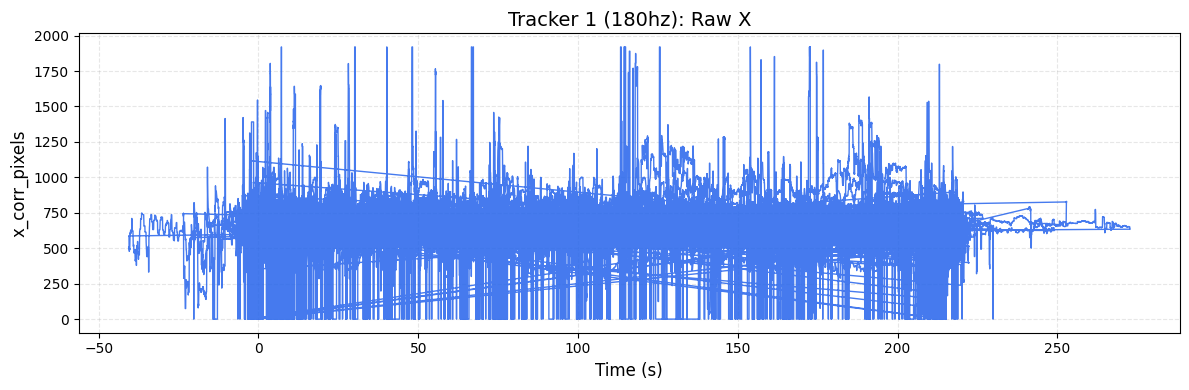

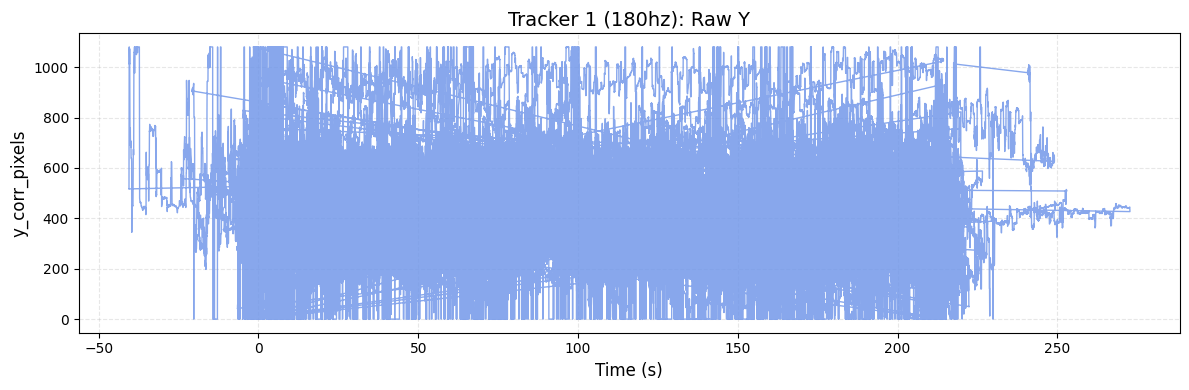

In [45]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df["times"], present_df["x_corr_pixels"], linewidth=1, color="#2563eb", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("x_corr_pixels", fontsize=12)
ax.set_title("Tracker 1 (180hz): Raw X", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df["times"], present_df["y_corr_pixels"], linewidth=1, color="#7398e9", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("y_corr_pixels", fontsize=12)
ax.set_title("Tracker 1 (180hz): Raw Y", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

##### 1. Remove Extreme (likely placeholder) values

In [ ]:
present_df = present_df[
    (present_df["x_corr_pixels"] > -3000) &
    (present_df["y_corr_pixels"] > -3000)
].reset_index(drop=True)

##### 2. Clip values to screen dimension

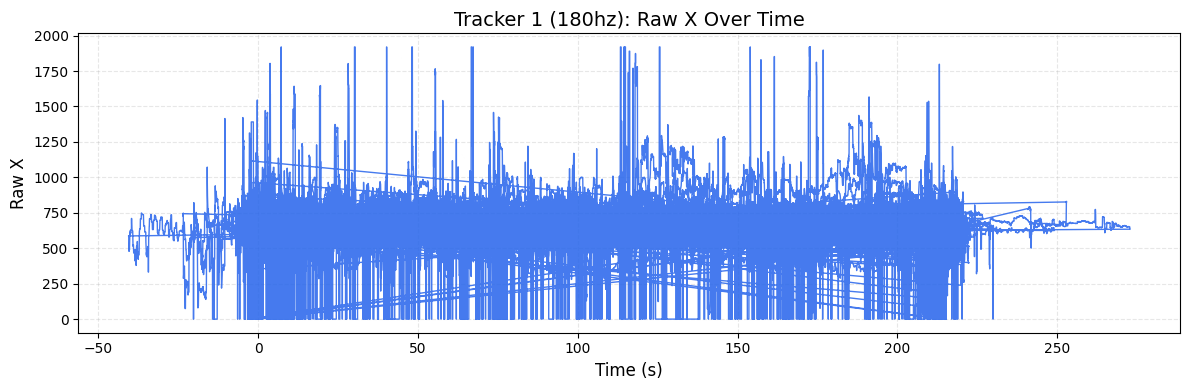

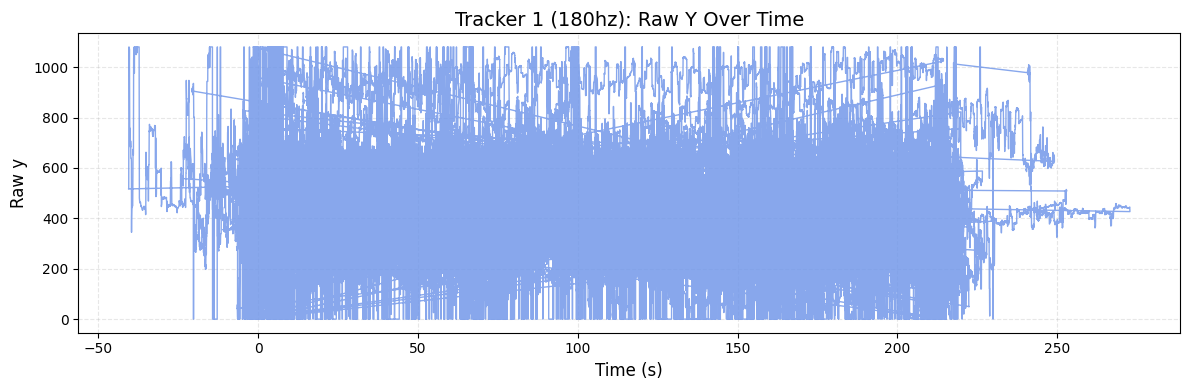

In [ ]:
SCREEN_W = 1920
SCREEN_H = 1080

present_df["x_corr_pixels"] = present_df["x_corr_pixels"].clip(0, SCREEN_W)
present_df["y_corr_pixels"] = present_df["y_corr_pixels"].clip(0, SCREEN_H)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df["times"], present_df["x_corr_pixels"], linewidth=1, color="#2563eb", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Raw X", fontsize=12)
ax.set_title("Tracker 1 (180hz): Raw X Over Time", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df["times"], present_df["y_corr_pixels"], linewidth=1, color="#7398e9", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Raw y", fontsize=12)
ax.set_title("Tracker 1 (180hz): Raw Y Over Time", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

##### 3. Butterworth Low Pass Filter

In [ ]:
sampling_rate = 180 
cutoff_freq = 20
filter_order = 2    

def butter_lowpass_filter(data, cutoff, fs, order=2):
    nyq = 0.5 * fs # Nyquist frequency
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # Apply filter forwards and backwards to eliminate phase distortion
    y = filtfilt(b, a, data)
    return y

# Apply the low pass filter
present_df['x_corr_pixels_butter'] = butter_lowpass_filter(present_df['x_corr_pixels'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)
present_df['y_corr_pixels_butter'] = butter_lowpass_filter(present_df['y_corr_pixels'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)

/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_18013/4205096229.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  present_df['x_corr_pixels_butter'] = butter_lowpass_filter(present_df['x_corr_pixels'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)
/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_18013/4205096229.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  present_df['y_corr_pixels_butter'] = butter_lowpass_filter(present_df['y_corr_pixels'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)


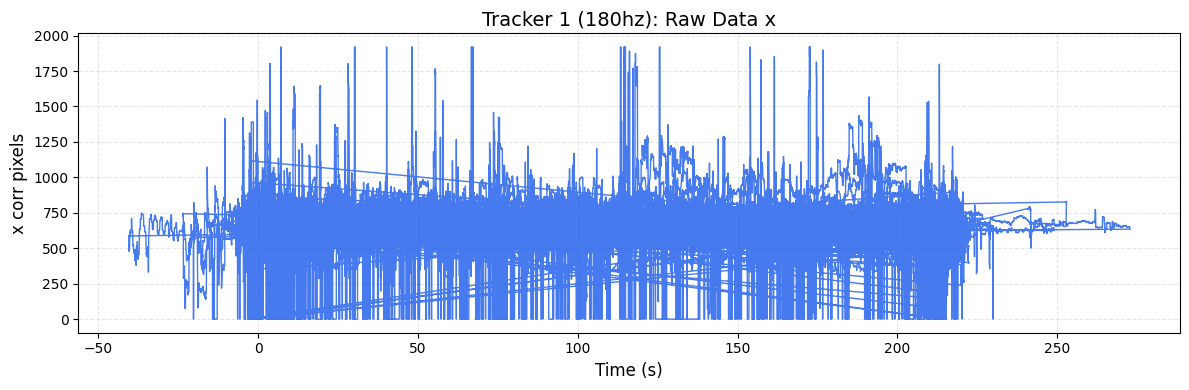

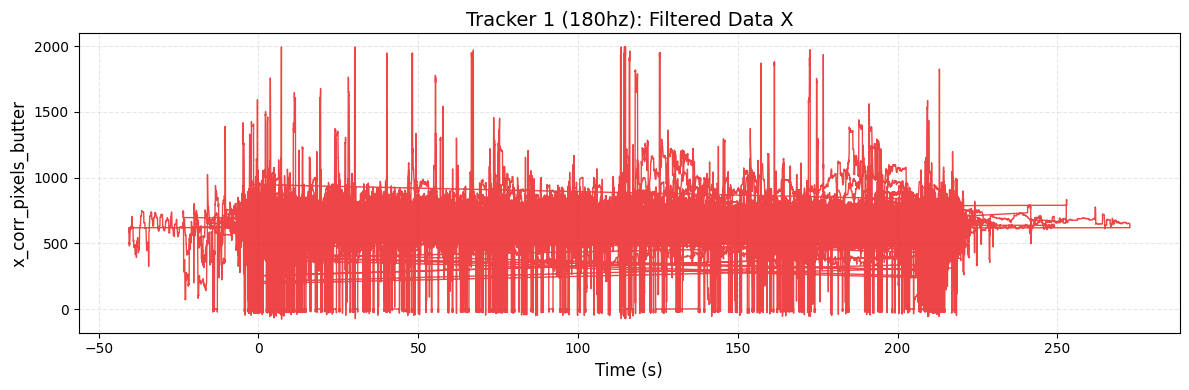

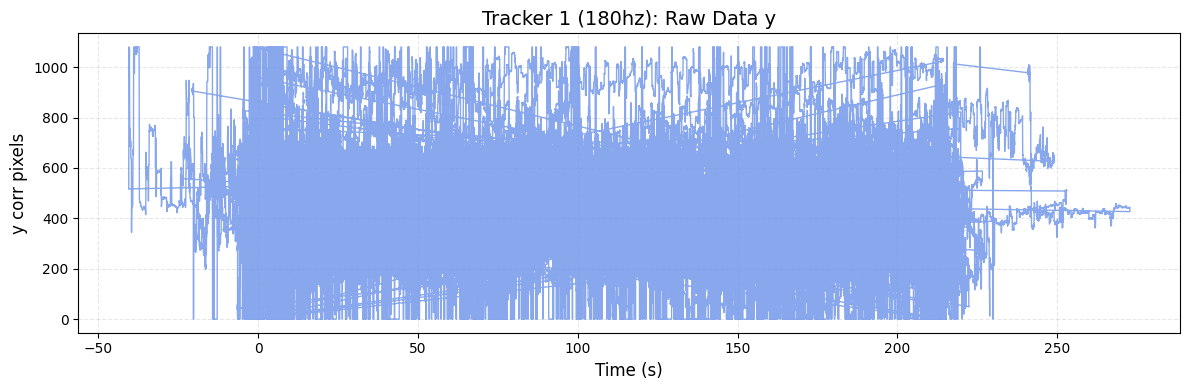

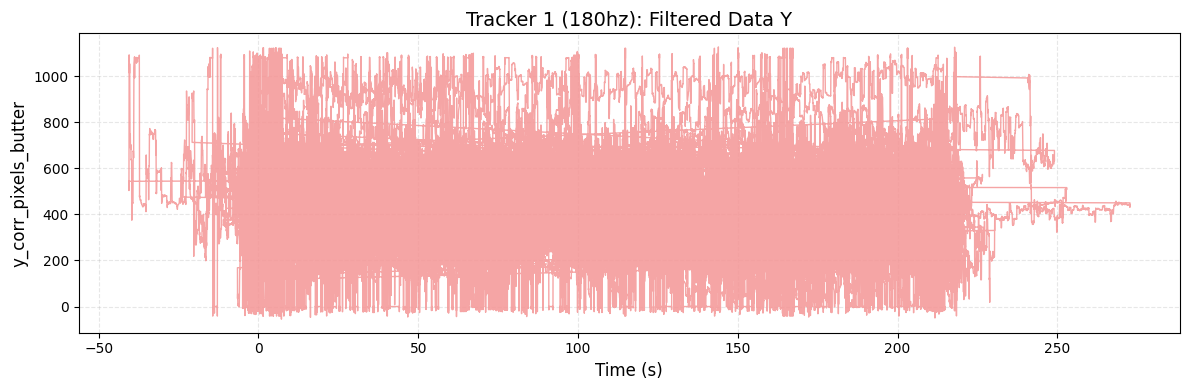

In [34]:
############ x 
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df["times"], present_df["x_corr_pixels"], linewidth=1, color="#2563eb", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("x corr pixels", fontsize=12)
ax.set_title("Tracker 1 (180hz): Raw Data x", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df["times"], present_df["x_corr_pixels_butter"], linewidth=1, color="#eb2525", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("x_corr_pixels_butter", fontsize=12)
ax.set_title("Tracker 1 (180hz): Filtered Data X", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

############ y
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df["times"], present_df["y_corr_pixels"], linewidth=1, color="#7398e9", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("y corr pixels", fontsize=12)
ax.set_title("Tracker 1 (180hz): Raw Data y", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df["times"], present_df["y_corr_pixels_butter"], linewidth=1, color="#f49595", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("y_corr_pixels_butter", fontsize=12)
ax.set_title("Tracker 1 (180hz): Filtered Data Y", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

#### Cacluate Eucledian Distance with Butterworth Filter 

In [ ]:
# Sort data by time per subject (to get time diference)
present_df = present_df.sort_values(by=["subjectID", "times"]).reset_index(drop=True)

# Calculate the difference (x2 - x1) and (y2 - y1) per subject
present_df["time_diff_x_butter"] = present_df.groupby("subjectID")["x_corr_pixels_butter"].diff()
present_df["time_diff_y_butter"] = present_df.groupby("subjectID")["y_corr_pixels_butter"].diff()

# Calculate Eucledian Distance: z = sqrt((x2-x1)^2 + (y2-y1)^2)
present_df["z_eucledian_dist_butter"] = np.sqrt(present_df["time_diff_x_butter"] ** 2 + present_df["time_diff_y_butter"] ** 2)

# Check Eucledian Distance
print(present_df.head())
print(descr_stats(present_df, 'z_eucledian_dist_butter'))

   x_corr_pixels  y_corr_pixels     times      subjectID  \
0          564.2          631.6 -1.122725  sub-A00010201   
1          564.3          630.9 -1.117170  sub-A00010201   
2          564.5          629.8 -1.111614  sub-A00010201   
3          564.7          628.0 -1.106058  sub-A00010201   
4          564.3          628.4 -1.100503  sub-A00010201   

   x_corr_pixels_butter  y_corr_pixels_butter  time_diff_x_butter  \
0            564.193622            631.598811                 NaN   
1            564.477386            630.518084            0.283764   
2            564.611707            629.548038            0.134322   
3            564.422541            628.838219           -0.189167   
4            563.741023            628.530402           -0.681518   

   time_diff_y_butter  z_eucledian_dist_butter  
0                 NaN                      NaN  
1           -1.080728                 1.117361  
2           -0.970045                 0.979301  
3           -0.709819       

Explore value 521 for Euclidean Distance

In [ ]:
## Find extreme value of z_eucledean_dist 
max_z_euclean_dist = present_df['z_eucledian_dist_butter'].max()
print(max_z_euclean_dist)
print(present_df.index[present_df["z_eucledian_dist_butter"] == max_z_euclean_dist])
target_index = 6810625

# Get window to view data 
start_index = target_index - 10
end_index = target_index + 10

# View data 
present_df.iloc[start_index:end_index]

Filter out extreme values of butter eucledian distance 

In [ ]:
#### Current number of samples
print("Current number of samples:", len(present_df))

# Filter out extreme values of Eucledian Distance 
z_eucledian_dist_butter_mean = present_df['z_eucledian_dist_butter'].mean()
z_eucledian_dist_butter_std = present_df['z_eucledian_dist_butter'].std()
upper_z_eucled = z_eucledian_dist_butter_mean + (2.5*z_eucledian_dist_butter_std)
lower_z_eucled = z_eucledian_dist_butter_mean - (2.5*z_eucledian_dist_butter_std)
print(upper_z_eucled)
print("Z EUCLEDIAN DISTANCE BEFORE")
print(f"mean: {z_eucledian_dist_butter_mean}; min: {present_df['z_eucledian_dist_butter'].min()}; max: {present_df['z_eucledian_dist_butter'].max()}") 

# filter 
present_df_plot = present_df[present_df['z_eucledian_dist_butter'] >= lower_z_eucled]
present_df_plot = present_df[present_df['z_eucledian_dist_butter'] <= upper_z_eucled]

print("*"*50)
print("Z EUCLEDIAN DISTANCE after filter")
print(f"mean: {present_df_plot['z_eucledian_dist_butter'].mean()}; min: {present_df_plot['z_eucledian_dist_butter'].min()}; max: {present_df_plot['z_eucledian_dist_butter'].max()}")
print("New samples:", len(present_df_plot))


Current number of samples: 7500577
14.372562044906608
Z EUCLEDIAN DISTANCE BEFORE
mean: 1.3612707323576914; min: 0.0; max: 521.3565771107748
**************************************************
Z EUCLEDIAN DISTANCE after filter
mean: 1.0572122575260199; min: 0.0; max: 14.37246497146482
New samples: 7431299


#### Recalculate ISC 

In [ ]:
df = present_df.copy()

# --- Interpolate onto time grid (same as before) ---
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

x_mat, y_mat = [], []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    x_mat.append(np.interp(time_grid, d['times'], d['x_corr_pixels_butter']))
    y_mat.append(np.interp(time_grid, d['times'], d['y_corr_pixels_butter']))

x_mat = np.array(x_mat)  # shape: (n_subjects, n_timepoints)
y_mat = np.array(y_mat)

n = len(subjects)

# --- Vectorized LOO mean ---
# Instead of recomputing mean of 299 subjects each time,
# subtract current subject from grand sum and divide by (n-1)
x_sum = x_mat.sum(axis=0)
y_sum = y_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    x_loo_mean = (x_sum - x_mat[i]) / (n - 1)
    y_loo_mean = (y_sum - y_mat[i]) / (n - 1)

    isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
    isc_y, _ = pearsonr(y_mat[i], y_loo_mean)

    isc_results.append({
        "subjectID": subj,
        "ISC_x": isc_x,
        "ISC_y": isc_y,
        "ISC_mean": np.nanmean([isc_x, isc_y])
    })

isc_df_present = pd.DataFrame(isc_results)
isc_df_present['rank_x'] = isc_df_present['ISC_x'].rank()
isc_df_present['rank_y'] = isc_df_present['ISC_y'].rank()
isc_df_present['rank_mean'] = isc_df_present['ISC_mean'].rank()
print(isc_df_present.head())
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

       subjectID     ISC_x     ISC_y  ISC_mean  rank_x  rank_y  rank_mean
0  sub-A00010201  0.692152  0.510321  0.601237   181.0   178.0      189.0
1  sub-A00010893  0.522432  0.500110  0.511271   144.0   173.0      178.0
2  sub-A00015273  0.494621  0.049772  0.272196   137.0    62.0      100.0
3  sub-A00017133  0.089508  0.089480  0.089494    47.0    69.0       39.0
4  sub-A00022607 -0.496428  0.007154 -0.244637     1.0    52.0        2.0


0

#### Plot with Butterworth Filter

In [ ]:
df = present_df_plot.merge(isc_df_present[["subjectID", "ISC_mean", "rank_mean"]], on="subjectID")
print(df.head())

   x_corr_pixels  y_corr_pixels     times      subjectID  \
0          564.3          630.9 -1.117170  sub-A00010201   
1          564.5          629.8 -1.111614  sub-A00010201   
2          564.7          628.0 -1.106058  sub-A00010201   
3          564.3          628.4 -1.100503  sub-A00010201   
4          563.1          628.8 -1.094947  sub-A00010201   

   x_corr_pixels_butter  y_corr_pixels_butter  time_diff_x_butter  \
0            564.477386            630.518084            0.283764   
1            564.611707            629.548038            0.134322   
2            564.422541            628.838219           -0.189167   
3            563.741023            628.530402           -0.681518   
4            562.466903            628.695176           -1.274120   

   time_diff_y_butter  z_eucledian_dist_butter  ISC_mean  rank_mean  
0           -1.080728                 1.117361  0.601237      189.0  
1           -0.970045                 0.979301  0.601237      189.0  
2           -0

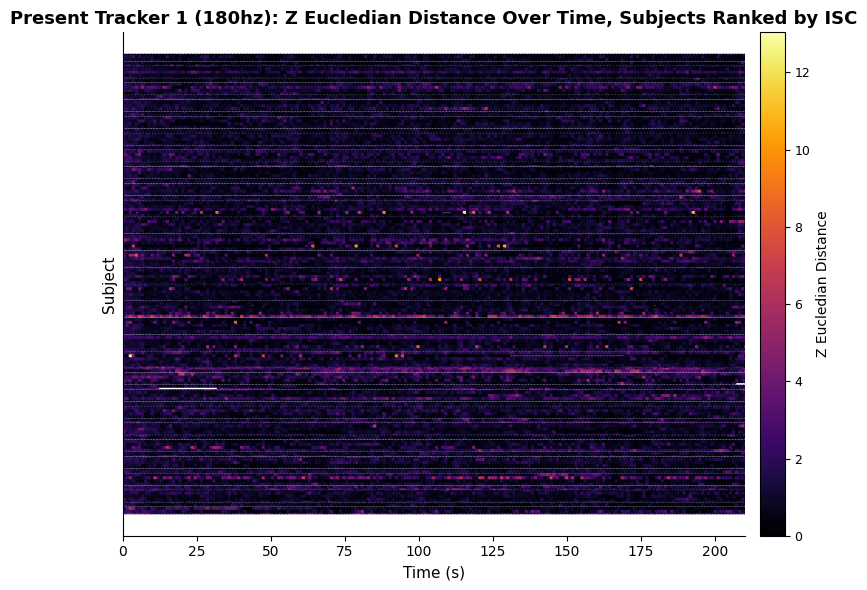

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_mean"],
    C=df["z_eucledian_dist_butter"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Z Eucledian Distance", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_y"].min(),
#                          df["rank_y"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df_sherlock.loc[isc_df_sherlock['rank_y'] == r, 'ISC_y'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis 
plt.xlim(0,210)

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("Present Tracker 1 (180hz): Z Eucledian Distance Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### DS2 *The Present* PLOT BUTTERWORTH FILTER

In [49]:
print(present_df2.head())
descr_stats(present_df2, "rightEyeX")
descr_stats(present_df2, "rightEyeY")

    rightEyeX   rightEyeY     times      subjectID
0  629.099976  518.599976 -1.367178  sub-A00008326
1  629.700012  519.400024 -1.365070  sub-A00008326
2  629.700012  519.400024 -1.363065  sub-A00008326
3  627.400024  524.000000 -1.361112  sub-A00008326
4  623.799988  529.200012 -1.359141  sub-A00008326
Summary stats for column: rightEyeX
mean    -1927.916931
min    -32768.000000
max      2559.699951
std      8921.628328
Name: rightEyeX, dtype: float64
Summary stats for column: rightEyeY
mean    -2058.005685
min    -32768.000000
max      2046.800049
std      8882.972553
Name: rightEyeY, dtype: float64


mean    -2058.005685
min    -32768.000000
max      2046.800049
std      8882.972553
Name: rightEyeY, dtype: float64

#### Clean and filter data 

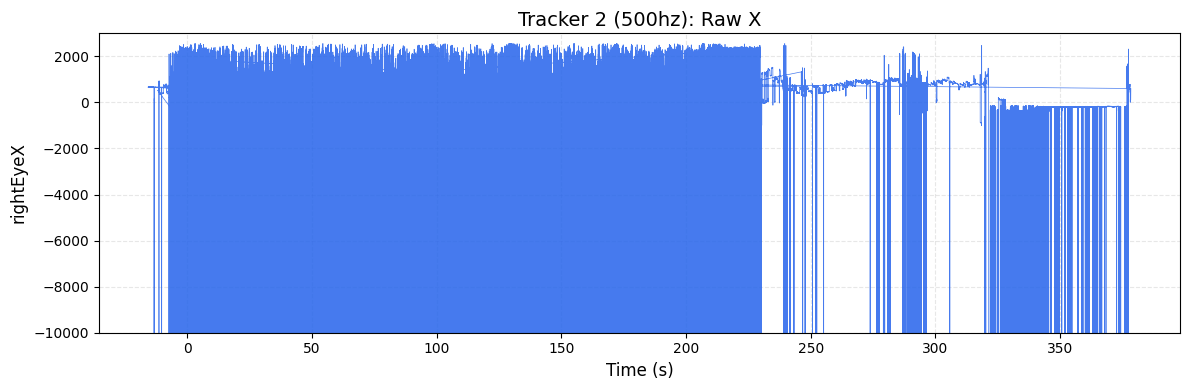

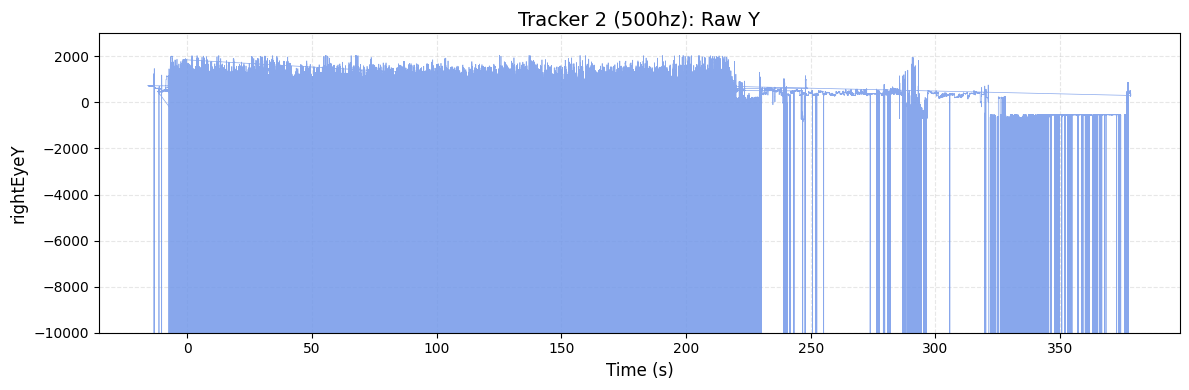

In [52]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df2["times"], present_df2["rightEyeX"], linewidth=.5, color="#2563eb", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("rightEyeX", fontsize=12)
ax.set_title("Tracker 2 (500hz): Raw X", fontsize=14)

ax.set_ylim(-10000, 3000) 
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df2["times"], present_df2["rightEyeY"], linewidth=.5, color="#7398e9", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("rightEyeY", fontsize=12)
ax.set_title("Tracker 2 (500hz): Raw Y", fontsize=14)

ax.set_ylim(-10000, 3000)  
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

##### 1. Remove Extreme (likely placeholder) values

In [54]:
present_df2 = present_df2[
    (present_df2["rightEyeX"] > -3000) &
    (present_df2["rightEyeY"] > -3000)
].reset_index(drop=True)

##### 2. Clip values to screen dimension

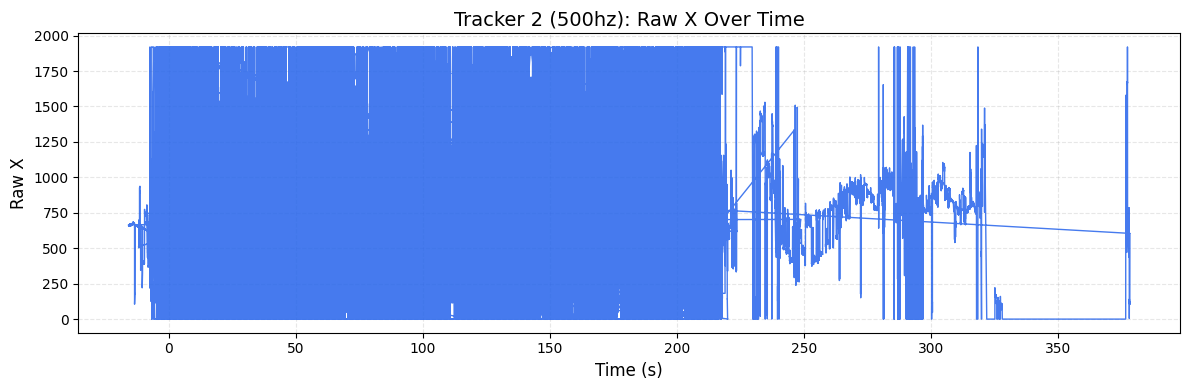

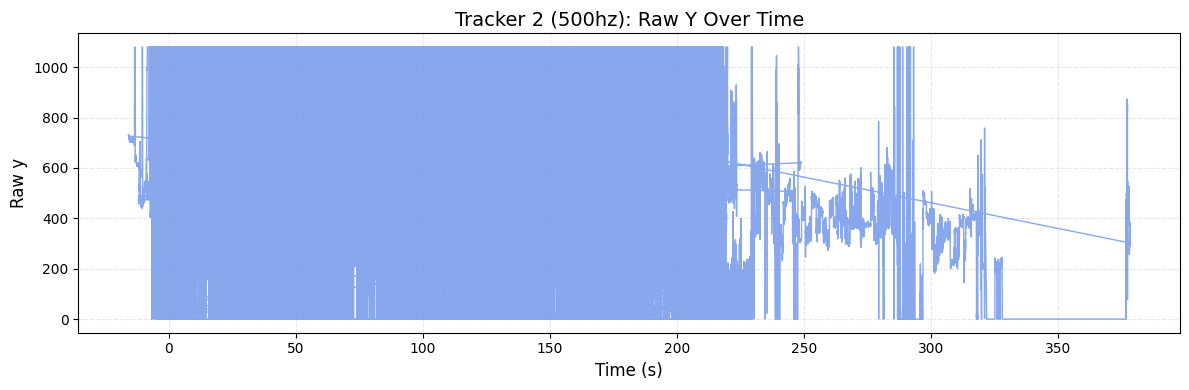

In [55]:
SCREEN_W = 1920
SCREEN_H = 1080

present_df2["rightEyeX"] = present_df2["rightEyeX"].clip(0, SCREEN_W)
present_df2["rightEyeY"] = present_df2["rightEyeY"].clip(0, SCREEN_H)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df2["times"], present_df2["rightEyeX"], linewidth=1, color="#2563eb", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Raw X", fontsize=12)
ax.set_title("Tracker 2 (500hz): Raw X Over Time", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df2["times"], present_df2["rightEyeY"], linewidth=1, color="#7398e9", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Raw y", fontsize=12)
ax.set_title("Tracker 2 (500hz): Raw Y Over Time", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

##### 3. Butterworth Low Pass Filter

In [56]:
sampling_rate = 500
cutoff_freq = 20
filter_order = 2    

def butter_lowpass_filter(data, cutoff, fs, order=2):
    nyq = 0.5 * fs # Nyquist frequency
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # Apply filter forwards and backwards to eliminate phase distortion
    y = filtfilt(b, a, data)
    return y

# Apply the low pass filter
present_df2['rightEyeX_butter'] = butter_lowpass_filter(present_df2['rightEyeX'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)
present_df2['rightEyeY_butter'] = butter_lowpass_filter(present_df2['rightEyeY'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)

/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_18013/2895383335.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  present_df2['rightEyeX_butter'] = butter_lowpass_filter(present_df2['rightEyeX'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)
/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_18013/2895383335.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  present_df2['rightEyeY_butter'] = butter_lowpass_filter(present_df2['rightEyeY'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)


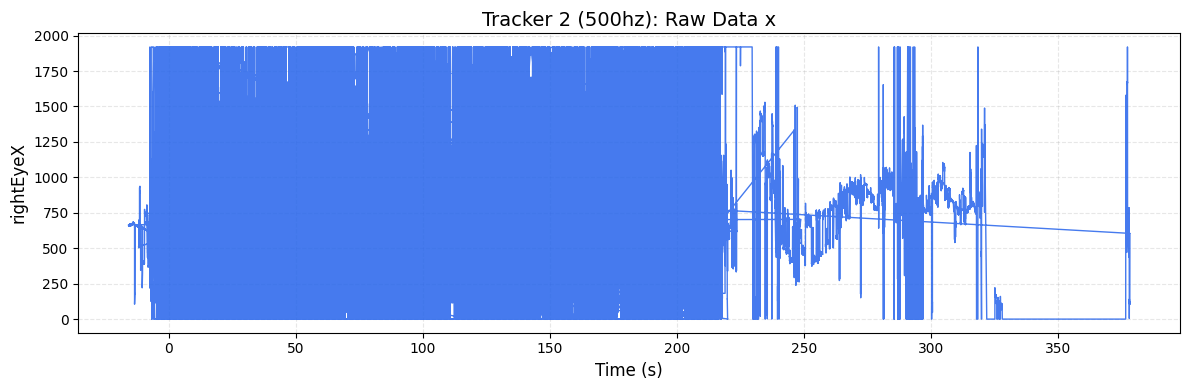

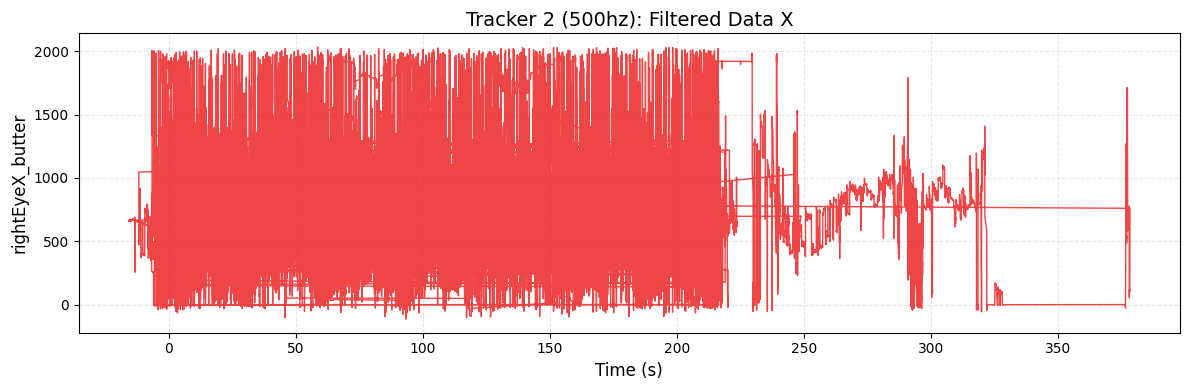

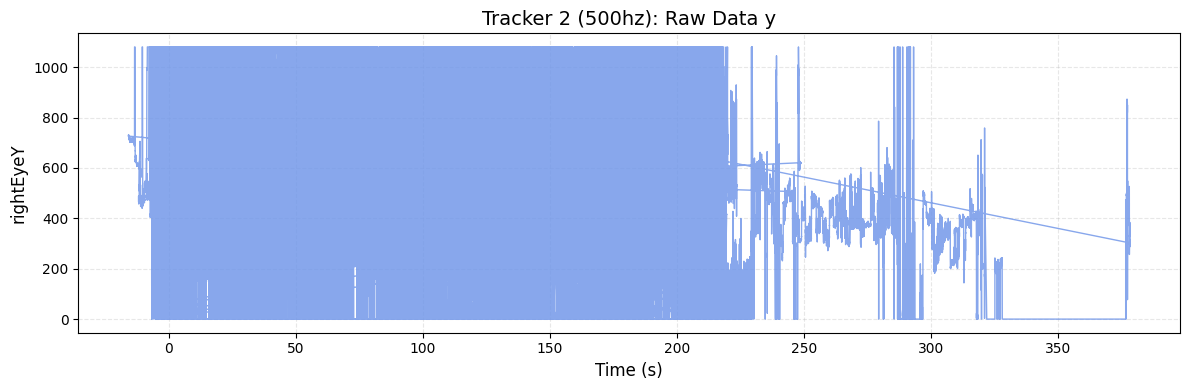

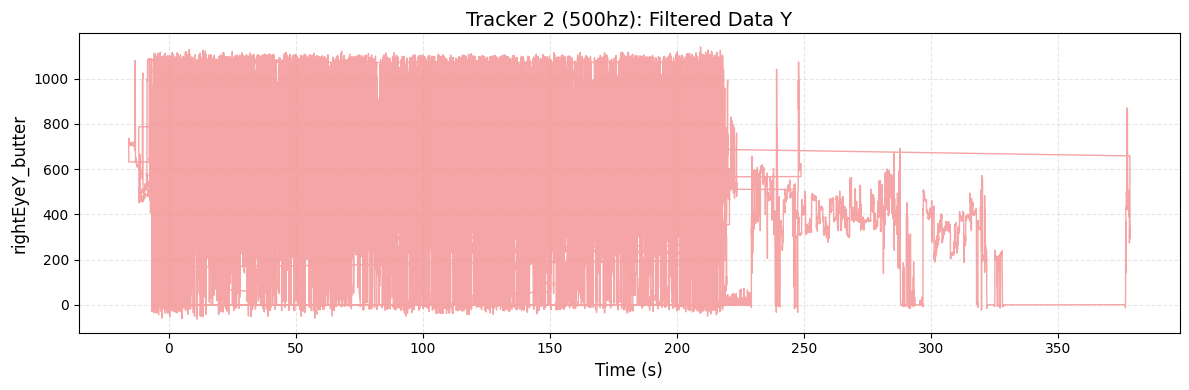

In [57]:
############ x 
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df2["times"], present_df2["rightEyeX"], linewidth=1, color="#2563eb", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("rightEyeX", fontsize=12)
ax.set_title("Tracker 2 (500hz): Raw Data x", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df2["times"], present_df2["rightEyeX_butter"], linewidth=1, color="#eb2525", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("rightEyeX_butter", fontsize=12)
ax.set_title("Tracker 2 (500hz): Filtered Data X", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

############ y
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df2["times"], present_df2["rightEyeY"], linewidth=1, color="#7398e9", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("rightEyeY", fontsize=12)
ax.set_title("Tracker 2 (500hz): Raw Data y", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_df2["times"], present_df2["rightEyeY_butter"], linewidth=1, color="#f49595", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("rightEyeY_butter", fontsize=12)
ax.set_title("Tracker 2 (500hz): Filtered Data Y", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

#### Cacluate Eucledian Distance with Butterworth Filter 

In [58]:
# Sort data by time per subject (to get time diference)
present_df2 = present_df2.sort_values(by=["subjectID", "times"]).reset_index(drop=True)

# Calculate the difference (x2 - x1) and (y2 - y1) per subject
present_df2["time_diff_x_butter"] = present_df2.groupby("subjectID")["rightEyeX_butter"].diff()
present_df2["time_diff_y_butter"] = present_df2.groupby("subjectID")["rightEyeY_butter"].diff()

# Calculate Eucledian Distance: z = sqrt((x2-x1)^2 + (y2-y1)^2)
present_df2["z_eucledian_dist_butter"] = np.sqrt(present_df2["time_diff_x_butter"] ** 2 + present_df2["time_diff_y_butter"] ** 2)

# Check Eucledian Distance
print(present_df2.head())
print(descr_stats(present_df2, 'z_eucledian_dist_butter'))

    rightEyeX   rightEyeY     times      subjectID  rightEyeX_butter  \
0  629.099976  518.599976 -1.367178  sub-A00008326        629.085894   
1  629.700012  519.400024 -1.365070  sub-A00008326        628.266905   
2  629.700012  519.400024 -1.363065  sub-A00008326        627.463261   
3  627.400024  524.000000 -1.361112  sub-A00008326        626.688462   
4  623.799988  529.200012 -1.359141  sub-A00008326        625.961067   

   rightEyeY_butter  time_diff_x_butter  time_diff_y_butter  \
0        518.686088                 NaN                 NaN   
1        520.778974           -0.818989            2.092885   
2        522.839618           -0.803645            2.060644   
3        524.835118           -0.774799            1.995500   
4        526.725666           -0.727395            1.890548   

   z_eucledian_dist_butter  
0                      NaN  
1                 2.247423  
2                 2.211809  
3                 2.140639  
4                 2.025655  
Summary stats 

Explore value 521 for Euclidean Distance

In [ ]:
## Find extreme value of z_eucledean_dist 
max_z_euclean_dist = present_df2['z_eucledian_dist_butter'].max()
print(max_z_euclean_dist)
print(present_df2.index[present_df2["z_eucledian_dist_butter"] == max_z_euclean_dist])
target_index = 6018198

# Get window to view data 
start_index = target_index - 10
end_index = target_index + 10

# View data 
present_df2.iloc[start_index:end_index]

Filter out extreme values of butter eucledian distance

In [ ]:
 #### Current number of samples
print("Current number of samples:", len(present_df2))

# Filter out extreme values of Eucledian Distance 
z_eucledian_dist_butter_mean = present_df2['z_eucledian_dist_butter'].mean()
z_eucledian_dist_butter_std = present_df2['z_eucledian_dist_butter'].std()
upper_z_eucled = z_eucledian_dist_butter_mean + (2.5*z_eucledian_dist_butter_std)
lower_z_eucled = z_eucledian_dist_butter_mean - (2.5*z_eucledian_dist_butter_std)
print("Z EUCLEDIAN DISTANCE BEFORE")
print(f"mean: {z_eucledian_dist_butter_mean}; min: {present_df2['z_eucledian_dist_butter'].min()}; max: {present_df2['z_eucledian_dist_butter'].max()}") 

# filter 
present_df2_plot = present_df2[present_df2['z_eucledian_dist_butter'] >= lower_z_eucled]
present_df2_plot = present_df2[present_df2['z_eucledian_dist_butter'] <= upper_z_eucled]

print("*"*50)
print("Z EUCLEDIAN DISTANCE after filter")
print(f"mean: {present_df2_plot['z_eucledian_dist_butter'].mean()}; min: {present_df2_plot['z_eucledian_dist_butter'].min()}; max: {present_df2_plot['z_eucledian_dist_butter'].max()}")
print("New samples:", len(present_df2_plot))


Current number of samples: 11560189
18.85069192763341
Z EUCLEDIAN DISTANCE BEFORE
mean: 1.9604054945409919; min: 0.0; max: 186.18414048569122
**************************************************
Z EUCLEDIAN DISTANCE after filter
mean: 1.1523674668587154; min: 0.0; max: 18.85059584566361
New samples: 11294133


#### Recalculate ISC

In [62]:
df = present_df2.copy()

# --- Interpolate onto time grid (same as before) ---
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

x_mat, y_mat = [], []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    x_mat.append(np.interp(time_grid, d['times'], d['rightEyeX_butter']))
    y_mat.append(np.interp(time_grid, d['times'], d['rightEyeY_butter']))

x_mat = np.array(x_mat)  # shape: (n_subjects, n_timepoints)
y_mat = np.array(y_mat)

n = len(subjects)

# --- Vectorized LOO mean ---
# Instead of recomputing mean of 299 subjects each time,
# subtract current subject from grand sum and divide by (n-1)
x_sum = x_mat.sum(axis=0)
y_sum = y_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    x_loo_mean = (x_sum - x_mat[i]) / (n - 1)
    y_loo_mean = (y_sum - y_mat[i]) / (n - 1)

    isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
    isc_y, _ = pearsonr(y_mat[i], y_loo_mean)

    isc_results.append({
        "subjectID": subj,
        "ISC_x": isc_x,
        "ISC_y": isc_y,
        "ISC_mean": np.nanmean([isc_x, isc_y])
    })

isc_df2_present = pd.DataFrame(isc_results)
isc_df2_present['rank_x'] = isc_df2_present['ISC_x'].rank()
isc_df2_present['rank_y'] = isc_df2_present['ISC_y'].rank()
isc_df2_present['rank_mean'] = isc_df2_present['ISC_mean'].rank()
print(isc_df2_present.head())
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

       subjectID     ISC_x     ISC_y  ISC_mean  rank_x  rank_y  rank_mean
0  sub-A00008326  0.184373 -0.183910  0.000232    20.0     9.0        6.0
1  sub-A00014880  0.418711  0.257055  0.337883    67.0    50.0       54.0
2  sub-A00015238  0.035776  0.511662  0.273719     8.0    83.0       36.0
3  sub-A00018181 -0.088052 -0.174782 -0.131417     3.0    10.0        4.0
4  sub-A00024751  0.342651  0.121389  0.232020    52.0    35.0       31.0


0

#### Plot with Butterworth Filter

In [63]:
df = present_df2_plot.merge(isc_df2_present[["subjectID", "ISC_mean", "rank_mean"]], on="subjectID")
print(df.head())

    rightEyeX   rightEyeY     times      subjectID  rightEyeX_butter  \
0  629.700012  519.400024 -1.365070  sub-A00008326        628.266905   
1  629.700012  519.400024 -1.363065  sub-A00008326        627.463261   
2  627.400024  524.000000 -1.361112  sub-A00008326        626.688462   
3  623.799988  529.200012 -1.359141  sub-A00008326        625.961067   
4  623.799988  529.200012 -1.357196  sub-A00008326        625.300780   

   rightEyeY_butter  time_diff_x_butter  time_diff_y_butter  \
0        520.778974           -0.818989            2.092885   
1        522.839618           -0.803645            2.060644   
2        524.835118           -0.774799            1.995500   
3        526.725666           -0.727395            1.890548   
4        528.469032           -0.660286            1.743365   

   z_eucledian_dist_butter  ISC_mean  rank_mean  
0                 2.247423  0.000232        6.0  
1                 2.211809  0.000232        6.0  
2                 2.140639  0.000232  

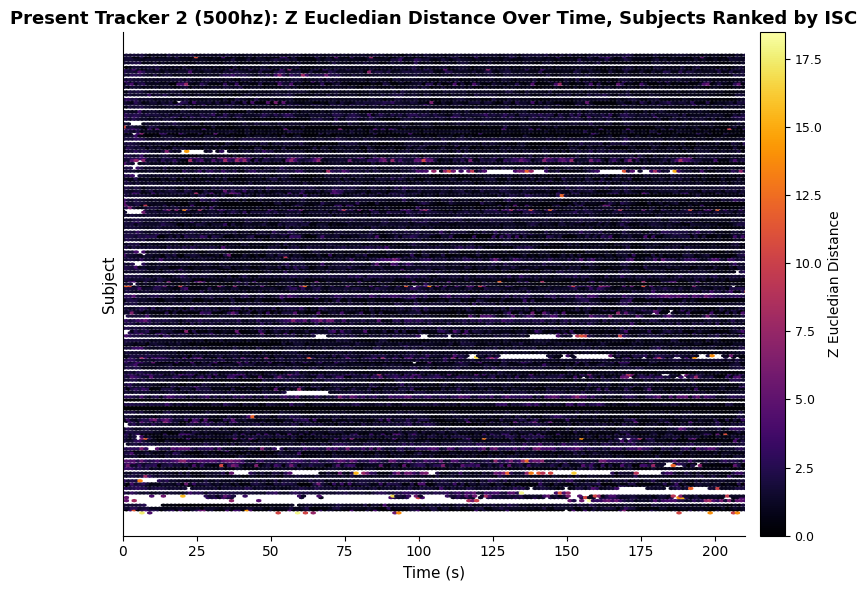

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_mean"],
    C=df["z_eucledian_dist_butter"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Z Eucledian Distance", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_y"].min(),
#                          df["rank_y"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df_sherlock.loc[isc_df_sherlock['rank_y'] == r, 'ISC_y'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis 
plt.xlim(0,210)

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("Present Tracker 2 (500hz): Z Eucledian Distance Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()